#  P653 – Diabetic Retinopathy Prediction
## Pipeline: EDA → Feature Engineering → Model Building

**Project Main Objective:** Binary classification — predict whether a patient will suffer  
from Diabetic Retinopathy (`retinopathy` / `no_retinopathy`) based on blood-test features.

| Feature | Description | Normal Range |
|---|---|---|
| age | Patient age (years) | — |
| systolic_bp | Systolic blood pressure | < 120 mmHg |
| diastolic_bp | Diastolic blood pressure | < 80 mmHg |
| cholesterol | Cholesterol level | 125–200 mg/dL |
| prognosis | **TARGET** (retinopathy / no_retinopathy) | — |


## 1️⃣ Data Loading & Initial Inspection

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, accuracy_score, f1_score, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer, KNNImputer
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='husl')
COLORS = ['#2196F3', '#F44336']

print("✅ All libraries imported successfully")


✅ All libraries imported successfully


In [26]:
import pandas as pd
# Load dataset (semicolon-separated)
df = pd.read_csv("C://Users//laksh//Downloads//P653_pronostico_dataset.csv", sep=';')

# Drop ID — not a predictive feature
df.drop(columns=['ID'], inplace=True)

# Encode target: retinopathy=1, no_retinopathy=0
df['prognosis'] = df['prognosis'].map({'retinopathy': 1, 'no_retinopathy': 0})

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head(10)


Dataset shape: (6000, 5)
Rows: 6,000 | Columns: 5


,age,systolic_bp,diastolic_bp,cholesterol,prognosis
0,77.196340,85.288742,80.021878,79.957109,1
1,63.529850,99.379736,84.852361,110.382411,1
2,69.003986,111.349455,109.850616,100.828246,1
3,82.638210,95.056128,79.666851,87.066303,1
4,78.346286,109.154591,90.713220,92.511770,1
5,52.181782,121.080264,110.488129,115.468279,1
6,68.722144,115.232290,92.730813,106.784960,1
7,58.716578,98.653683,94.172130,100.829654,1
8,59.121758,102.681371,96.991612,106.331045,1
9,63.624683,96.341053,80.919213,121.558605,1


In [27]:
print("=" * 55)
print("BASIC INFO")
print("=" * 55)
df.info()


BASIC INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           6000 non-null   float64
 1   systolic_bp   6000 non-null   float64
 2   diastolic_bp  6000 non-null   float64
 3   cholesterol   6000 non-null   float64
 4   prognosis     6000 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 234.5 KB


In [28]:
print("=" * 55)
print("DESCRIPTIVE STATISTICS")
print("=" * 55)
df.describe().round(3)

DESCRIPTIVE STATISTICS


,age,systolic_bp,diastolic_bp,cholesterol,prognosis
count,6000.000,6000.000,6000.000,6000.000,6000.000
mean,60.464,100.695,90.506,100.628,0.514
std,8.564,10.669,9.648,10.434,0.500
min,35.165,69.675,62.807,69.967,0.000
25%,54.372,93.267,83.642,93.202,0.000
50%,59.831,100.120,89.912,100.061,1.000
75%,65.810,107.440,96.682,107.251,1.000
max,103.279,151.700,133.456,148.234,1.000


## 2️⃣ Missing Value Analysis & Imputation Strategy



Missing Value Summary:
              Count  Percentage (%)
age               0             0.0
systolic_bp       0             0.0
diastolic_bp      0             0.0
cholesterol       0             0.0
prognosis         0             0.0



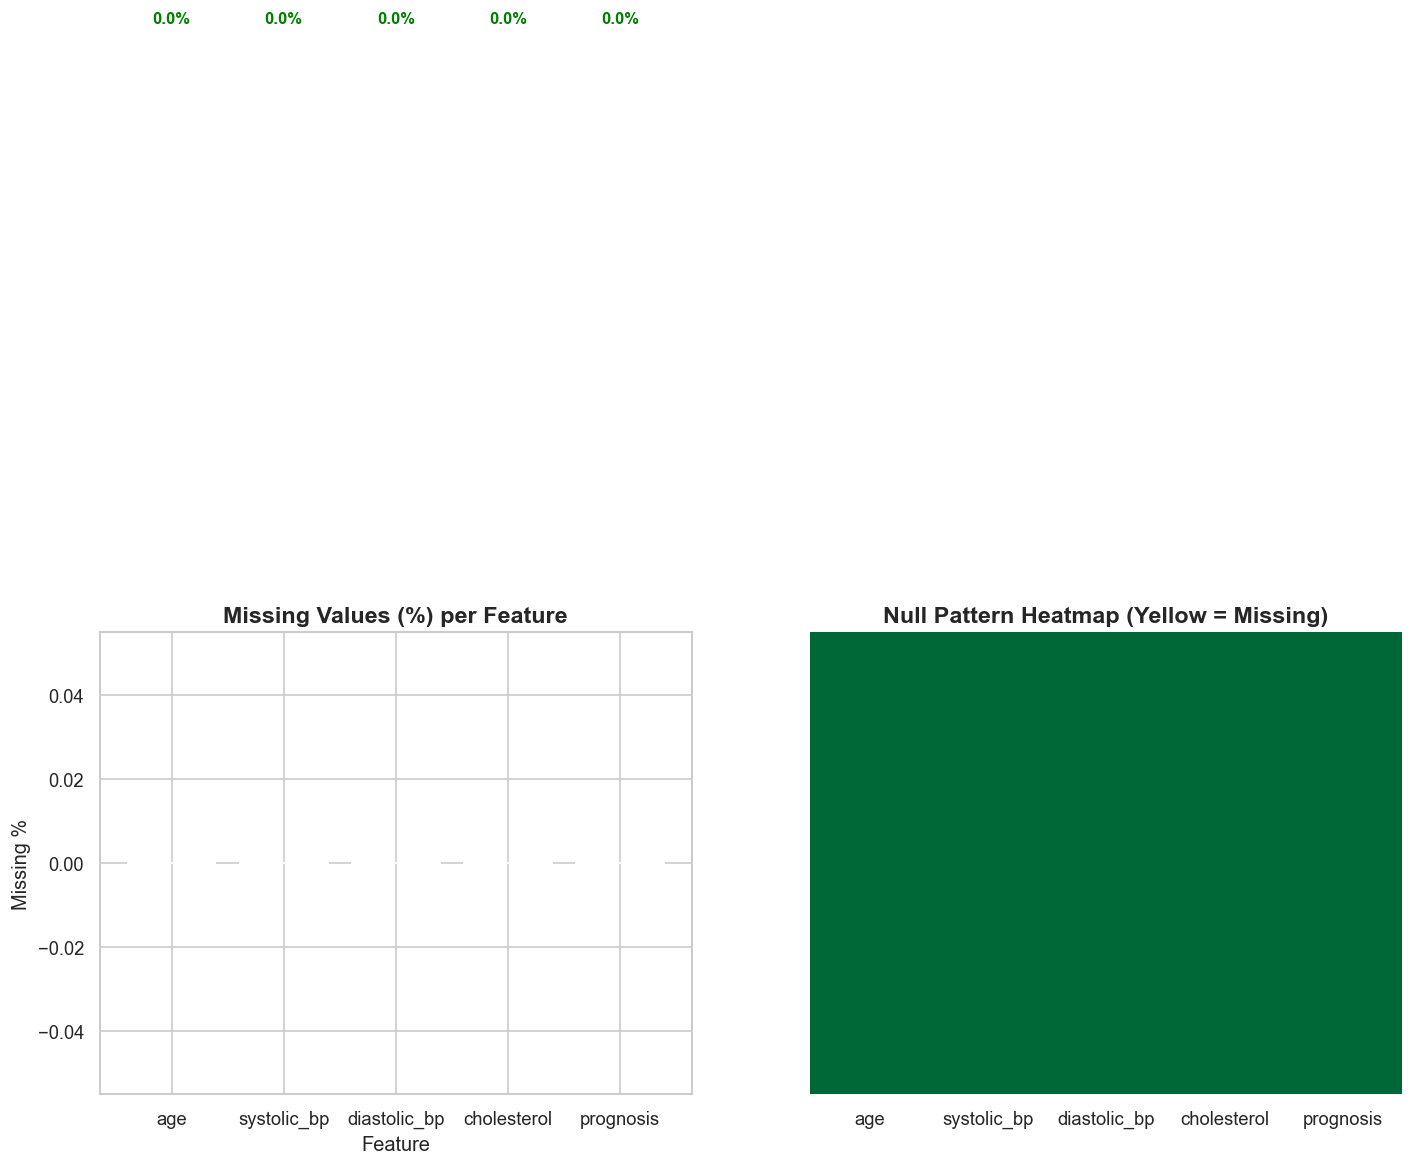


📌 INSIGHT: Check if any imputation is needed (green bars = no missing data)


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# ── Missing Value Heatmap ──────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})

print("Missing Value Summary:")
print(missing_df)
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#F44336' if v > 0 else '#4CAF50' for v in missing.values]
axes[0].bar(missing.index, missing_pct.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Missing Values (%) per Feature', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Missing %')
axes[0].set_xlabel('Feature')
for i, (val, pct) in enumerate(zip(missing.values, missing_pct.values)):
    axes[0].text(i, pct + 0.2, f'{pct:.1f}%', ha='center', fontsize=10,
                 color='green' if pct == 0 else 'red', fontweight='bold')

# Heatmap of nulls
sns.heatmap(df.isnull(), cbar=False, yticklabels=False,
            cmap='RdYlGn_r', ax=axes[1])
axes[1].set_title('Null Pattern Heatmap (Yellow = Missing)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('01_missing_values.png', bbox_inches='tight')
plt.show()
print("\n📌 INSIGHT: Check if any imputation is needed (green bars = no missing data)")


In [30]:
# ── Imputation Strategy Decision Tree ─────────────────────────
print("""
╔══════════==══════════════════════════════════════════════════╗
║           IMPUTATION STRATEGY ANALYSIS                       ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  STEP 1 → Check missing % per column                        ║
║     • 0%        → No imputation needed ✅                   ║
║     • < 5%      → Mean/Median imputation (safe)             ║
║     • 5–20%     → KNN Imputer (preserves relationships)     ║
║     • 20–40%    → Multiple Imputation (MICE)                ║
║     • > 40%     → Drop column (unreliable)                  ║
║                                                              ║
║  STEP 2 → Check distribution of missing column              ║
║     • Normal distribution  → Mean imputation                ║
║     • Skewed distribution  → Median imputation              ║
║     • Categorical column   → Mode imputation                ║
║                                                              ║
║  STEP 3 → Check MCAR / MAR / MNAR pattern                   ║
║     • MCAR (Missing Completely At Random) → Any method OK   ║
║     • MAR  (Missing At Random)            → KNN / Regression║
║     • MNAR (Not At Random)                → Domain-specific ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")

# Determine & apply appropriate imputation
num_cols = ['age', 'systolic_bp', 'diastolic_bp', 'cholesterol']
for col in num_cols:
    miss_pct = df[col].isnull().sum() / len(df) * 100
    skew_val = df[col].skew()
    if miss_pct == 0:
        strategy = "✅ No Imputation Needed"
    elif miss_pct < 5:
        if abs(skew_val) < 0.5:
            strategy = f"→ Mean Imputation (skew={skew_val:.2f}, approx normal)"
            df[col].fillna(df[col].mean(), inplace=True)
        else:
            strategy = f"→ Median Imputation (skew={skew_val:.2f}, skewed)"
            df[col].fillna(df[col].median(), inplace=True)
    elif miss_pct < 20:
        strategy = f"→ KNN Imputation (miss={miss_pct:.1f}%)"
    else:
        strategy = f"⚠️ High Missing: {miss_pct:.1f}% — review column"
    print(f"  {col:15s} | Missing: {miss_pct:5.1f}% | Skew: {skew_val:+.2f} | {strategy}")

print("\n✅ Imputation decisions applied.")



╔══════════==══════════════════════════════════════════════════╗
║           IMPUTATION STRATEGY ANALYSIS                       ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  STEP 1 → Check missing % per column                        ║
║     • 0%        → No imputation needed ✅                   ║
║     • < 5%      → Mean/Median imputation (safe)             ║
║     • 5–20%     → KNN Imputer (preserves relationships)     ║
║     • 20–40%    → Multiple Imputation (MICE)                ║
║     • > 40%     → Drop column (unreliable)                  ║
║                                                              ║
║  STEP 2 → Check distribution of missing column              ║
║     • Normal distribution  → Mean imputation                ║
║     • Skewed distribution  → Median imputation              ║
║     • Categorical column   → Mode imputation                ║
║                                  

## 3️⃣ Target Variable Analysis (Class Balance)

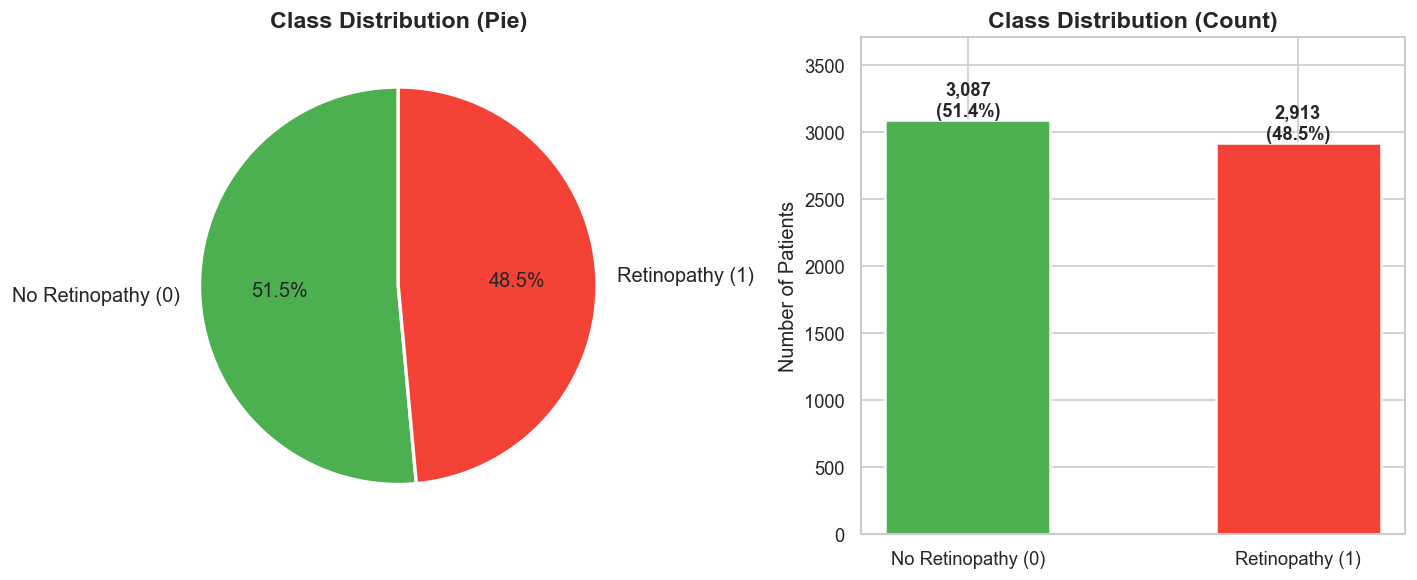


📌 Class ratio: 1.06:1
✅ Classes are reasonably balanced.


In [31]:
# Required libraries
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

COLORS = ['#4CAF50', '#F44336']
target_counts = df['prognosis'].value_counts()
labels = ['No Retinopathy (0)', 'Retinopathy (1)']

# Pie chart
axes[0].pie(target_counts.values, labels=labels, colors=COLORS,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2),
            textprops={'fontsize': 12})
axes[0].set_title('Class Distribution (Pie)', fontsize=14, fontweight='bold')

# Count bar
bars = axes[1].bar(labels, target_counts.values, color=COLORS, edgecolor='white',
                   linewidth=1.5, width=0.5)
axes[1].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Patients')
for bar, val in zip(bars, target_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, max(target_counts.values) * 1.2)

plt.tight_layout()
plt.savefig('02_target_distribution.png', bbox_inches='tight')
plt.show()

ratio = target_counts.max() / target_counts.min()
print(f"\n📌 Class ratio: {ratio:.2f}:1")
if ratio > 1.5:
    print("⚠️  Class imbalance detected! Consider: SMOTE / class_weight='balanced'")
else:
    print("✅ Classes are reasonably balanced.")


## 4️⃣ Univariate Analysis — Feature Distributions

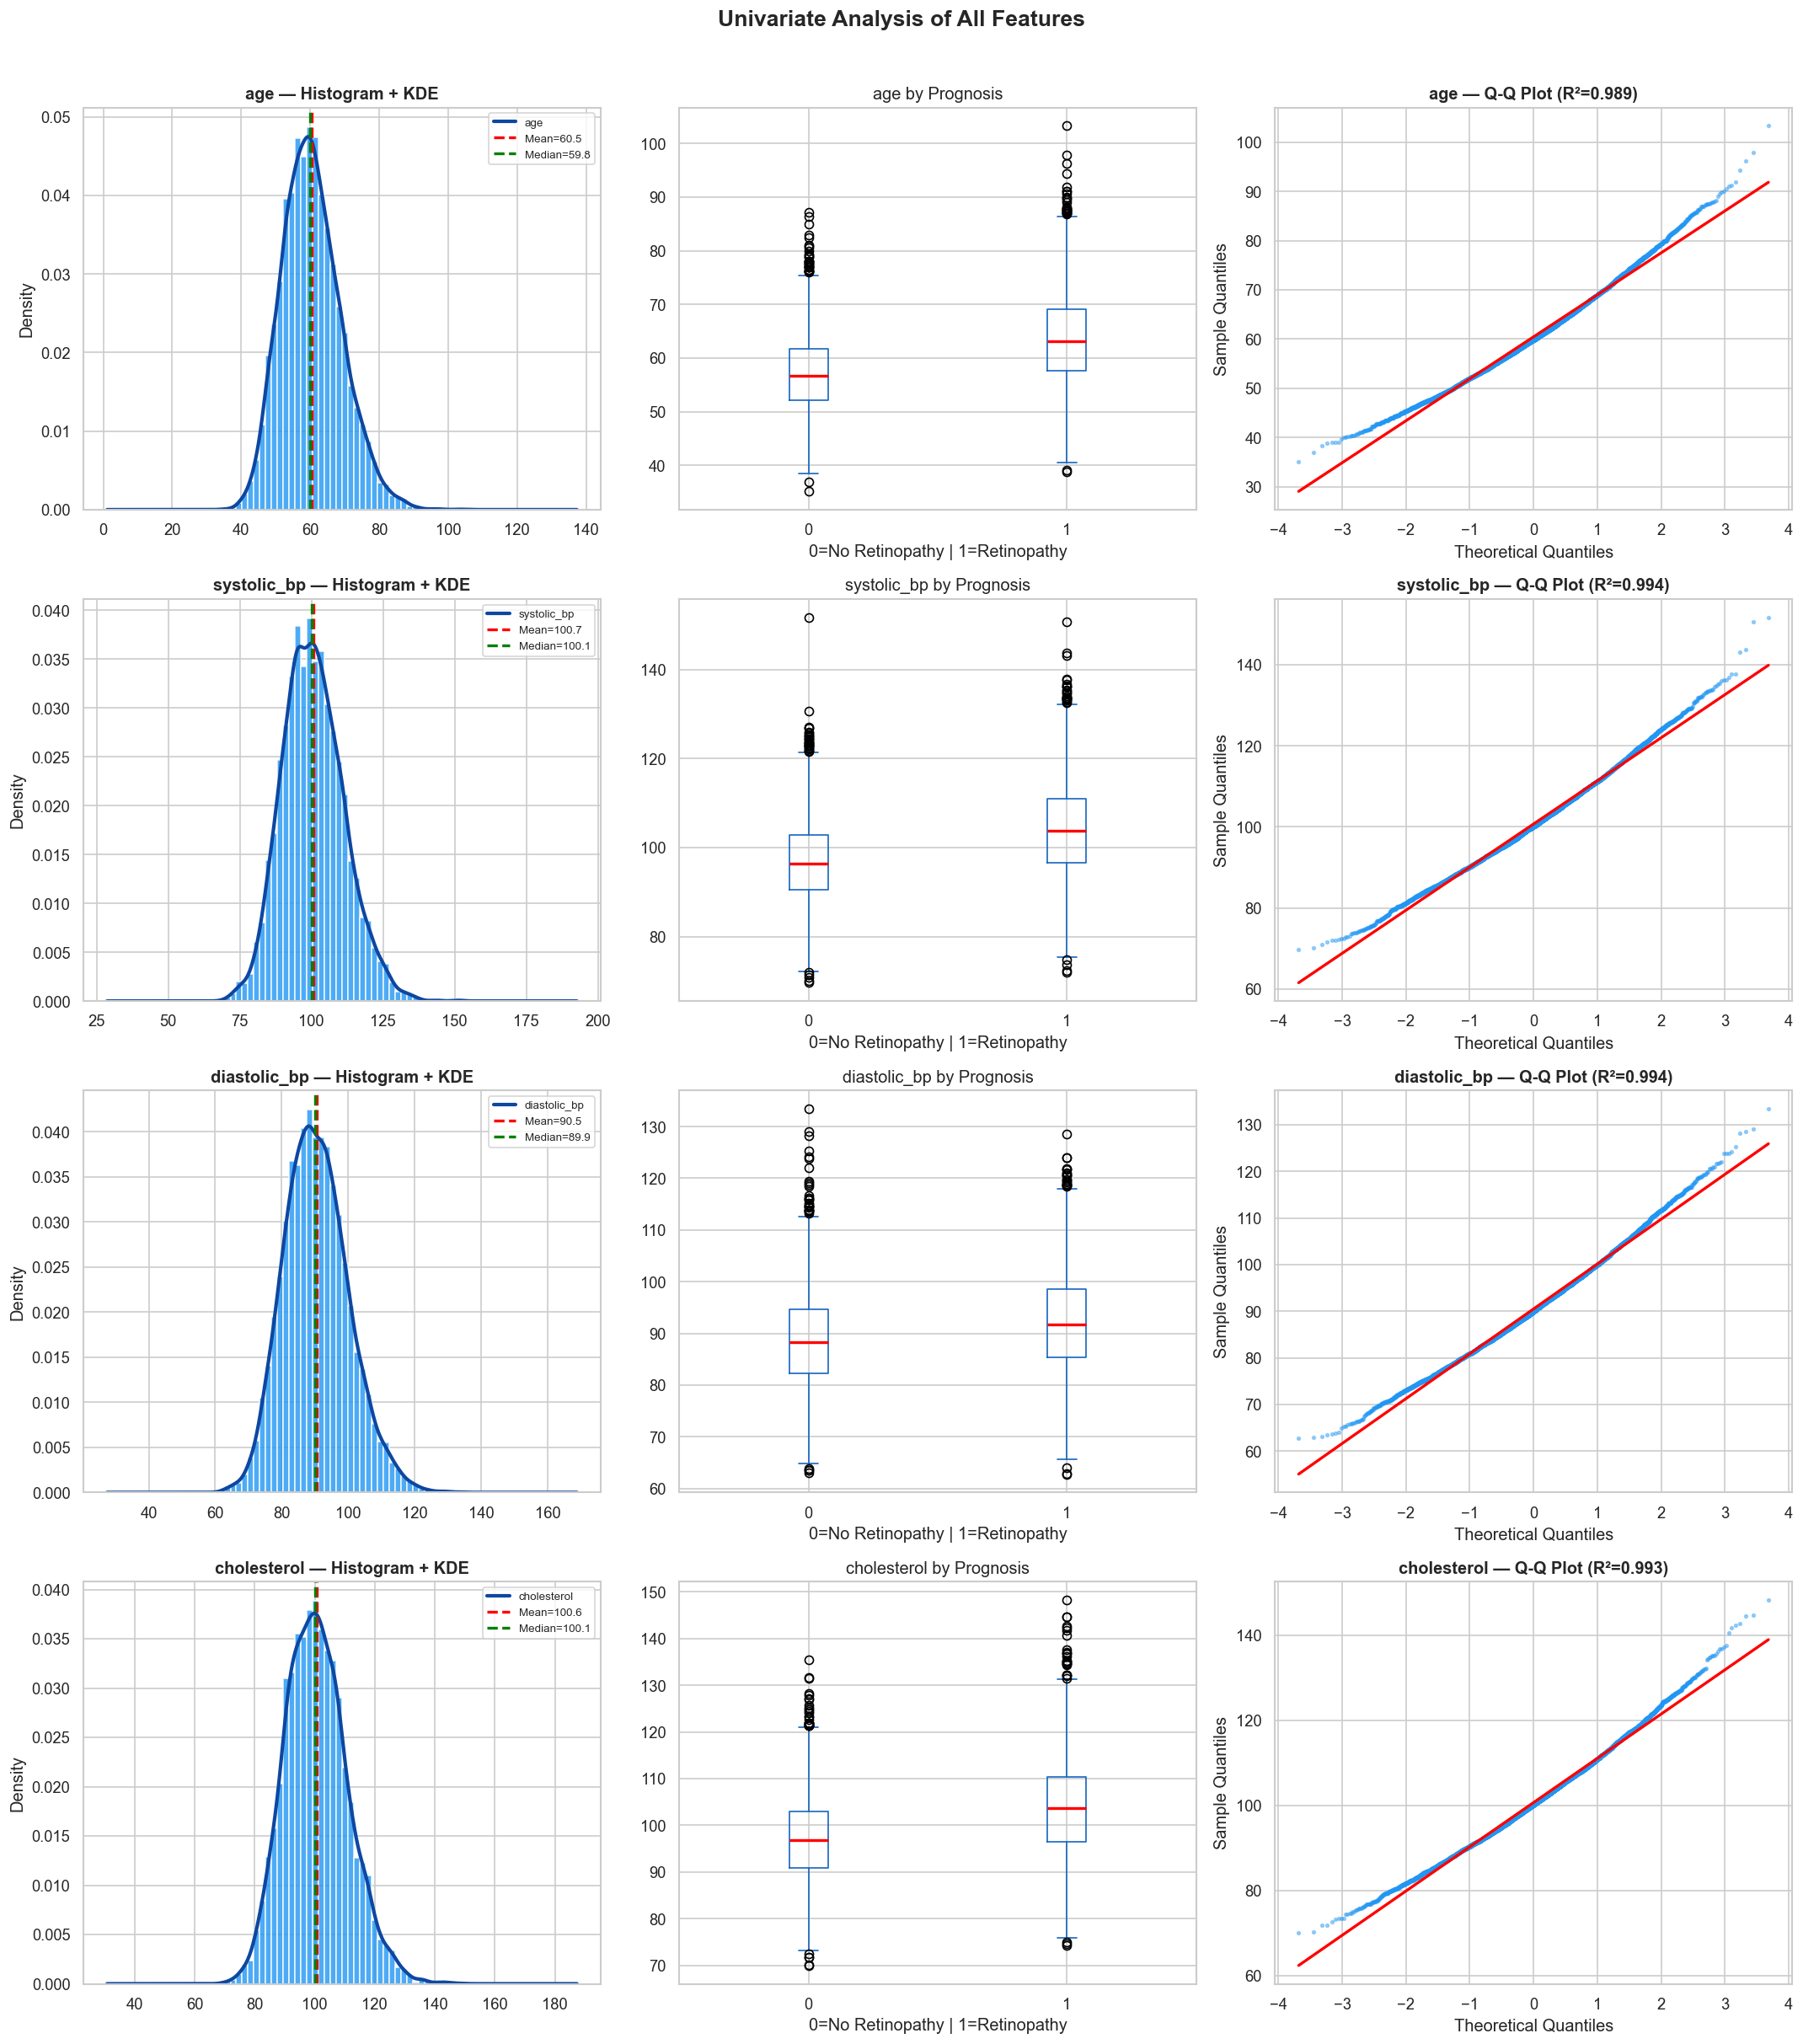

In [32]:
# Required libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
num_cols = ['age', 'systolic_bp', 'diastolic_bp', 'cholesterol']
fig, axes = plt.subplots(4, 3, figsize=(18, 20))

for i, col in enumerate(num_cols):
    data = df[col].dropna()

    # Histogram + KDE
    axes[i, 0].hist(data, bins=40, color='#2196F3', edgecolor='white', alpha=0.8, density=True)
    data.plot.kde(ax=axes[i, 0], color='#0D47A1', linewidth=2.5)
    axes[i, 0].axvline(data.mean(), color='red', ls='--', lw=2, label=f'Mean={data.mean():.1f}')
    axes[i, 0].axvline(data.median(), color='green', ls='--', lw=2, label=f'Median={data.median():.1f}')
    axes[i, 0].set_title(f'{col} — Histogram + KDE', fontweight='bold')
    axes[i, 0].legend(fontsize=8)

    # Boxplot split by target
    df.boxplot(column=col, by='prognosis', ax=axes[i, 1],
               boxprops=dict(color='#1565C0'), medianprops=dict(color='red', lw=2),
               whiskerprops=dict(color='#1565C0'), capprops=dict(color='#1565C0'))
    axes[i, 1].set_title(f'{col} by Target', fontweight='bold')
    axes[i, 1].set_xlabel('0=No Retinopathy | 1=Retinopathy')
    plt.sca(axes[i, 1])
    plt.title(f'{col} by Prognosis')

    # QQ-plot
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    axes[i, 2].scatter(osm, osr, color='#2196F3', alpha=0.4, s=5)
    axes[i, 2].plot(osm, slope * np.array(osm) + intercept, color='red', lw=2)
    axes[i, 2].set_title(f'{col} — Q-Q Plot (R²={r**2:.3f})', fontweight='bold')
    axes[i, 2].set_xlabel('Theoretical Quantiles')
    axes[i, 2].set_ylabel('Sample Quantiles')

plt.suptitle('Univariate Analysis of All Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('03_univariate_analysis.png', bbox_inches='tight')
plt.show()


In [33]:
# Required library
import pandas as pd
# ── Skewness & Kurtosis Table ──────────────────────────────────
print("=" * 60)
print("DISTRIBUTION METRICS")
print("=" * 60)
stats_df = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Std': df[num_cols].std(),
    'Skewness': df[num_cols].skew(),
    'Kurtosis': df[num_cols].kurtosis(),
    'Min': df[num_cols].min(),
    'Max': df[num_cols].max()
}).round(3)
print(stats_df.to_string())
print()
print("📌 INSIGHTS:")
for col in num_cols:
    sk = df[col].skew()
    ku = df[col].kurtosis()
    norm_flag = "✅ ~Normal" if abs(sk) < 0.5 else ("📉 Left-Skewed" if sk < 0 else "📈 Right-Skewed")
    print(f"  {col:15s}: Skew={sk:+.3f} ({norm_flag}) | Kurtosis={ku:.3f}")


DISTRIBUTION METRICS
                 Mean   Median     Std  Skewness  Kurtosis     Min      Max
age            60.464   59.831   8.564     0.441     0.275  35.165  103.279
systolic_bp   100.695  100.120  10.669     0.335     0.213  69.675  151.700
diastolic_bp   90.506   89.912   9.648     0.337     0.162  62.807  133.456
cholesterol   100.628  100.061  10.434     0.362     0.260  69.967  148.234

📌 INSIGHTS:
  age            : Skew=+0.441 (✅ ~Normal) | Kurtosis=0.275
  systolic_bp    : Skew=+0.335 (✅ ~Normal) | Kurtosis=0.213
  diastolic_bp   : Skew=+0.337 (✅ ~Normal) | Kurtosis=0.162
  cholesterol    : Skew=+0.362 (✅ ~Normal) | Kurtosis=0.260


## 5️⃣ Outlier Detection (IQR & Z-Score)

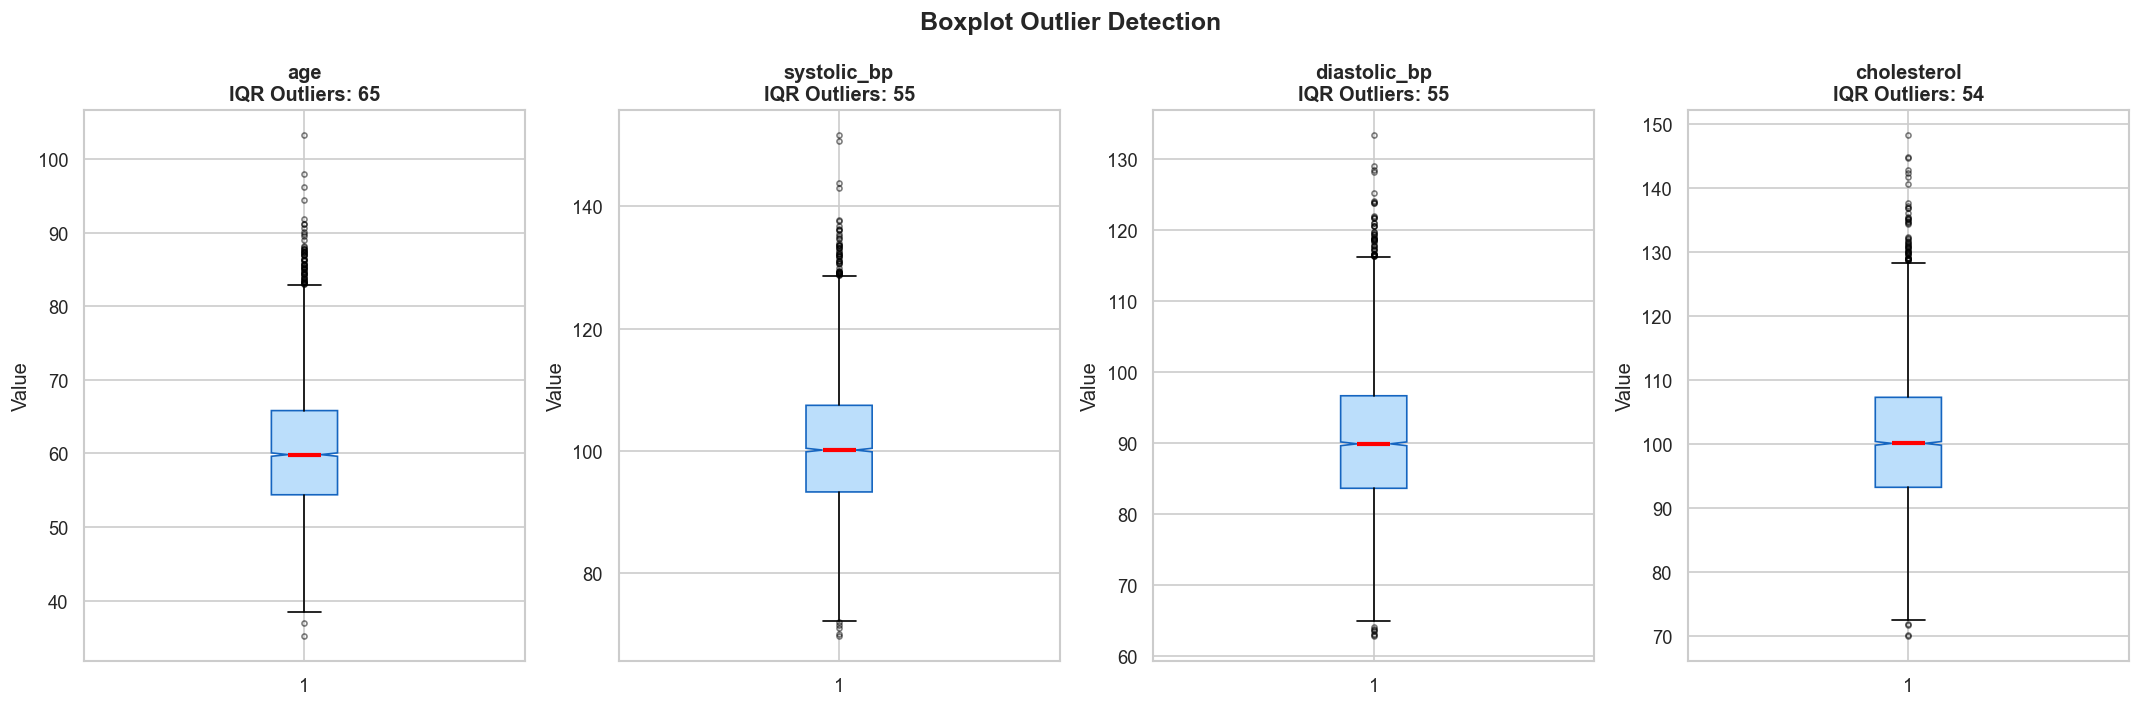


Outlier Summary:


,IQR Outliers,Z-Score Outliers,IQR Lower,IQR Upper
age,65.0,30.0,37.22,82.97
systolic_bp,55.0,22.0,72.01,128.70
diastolic_bp,55.0,21.0,64.08,116.24
cholesterol,54.0,22.0,72.13,128.32


In [34]:
#### Outlier Detection using IQR and Z-Score
# Required libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

outlier_summary = {}
for i, col in enumerate(num_cols):
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    iqr_out = ((data < lower) | (data > upper)).sum()
    z_out = (np.abs(stats.zscore(data)) > 3).sum()
    outlier_summary[col] = {'IQR Outliers': iqr_out, 'Z-Score Outliers': z_out,
                             'IQR Lower': lower, 'IQR Upper': upper}

    bp = axes[i].boxplot(data, patch_artist=True, notch=True,
                         boxprops=dict(facecolor='#BBDEFB', color='#1565C0'),
                         medianprops=dict(color='red', lw=2.5),
                         flierprops=dict(marker='o', color='#F44336', alpha=0.5, markersize=3))
    axes[i].set_title(f'{col}\nIQR Outliers: {iqr_out}', fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplot Outlier Detection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('04_outlier_detection.png', bbox_inches='tight')
plt.show()

print("\nOutlier Summary:")
pd.DataFrame(outlier_summary).T.round(2)


## 6️⃣ Bivariate Analysis — Features vs Target
Compare feature distributions between retinopathy and non-retinopathy patients to identify significant differences.

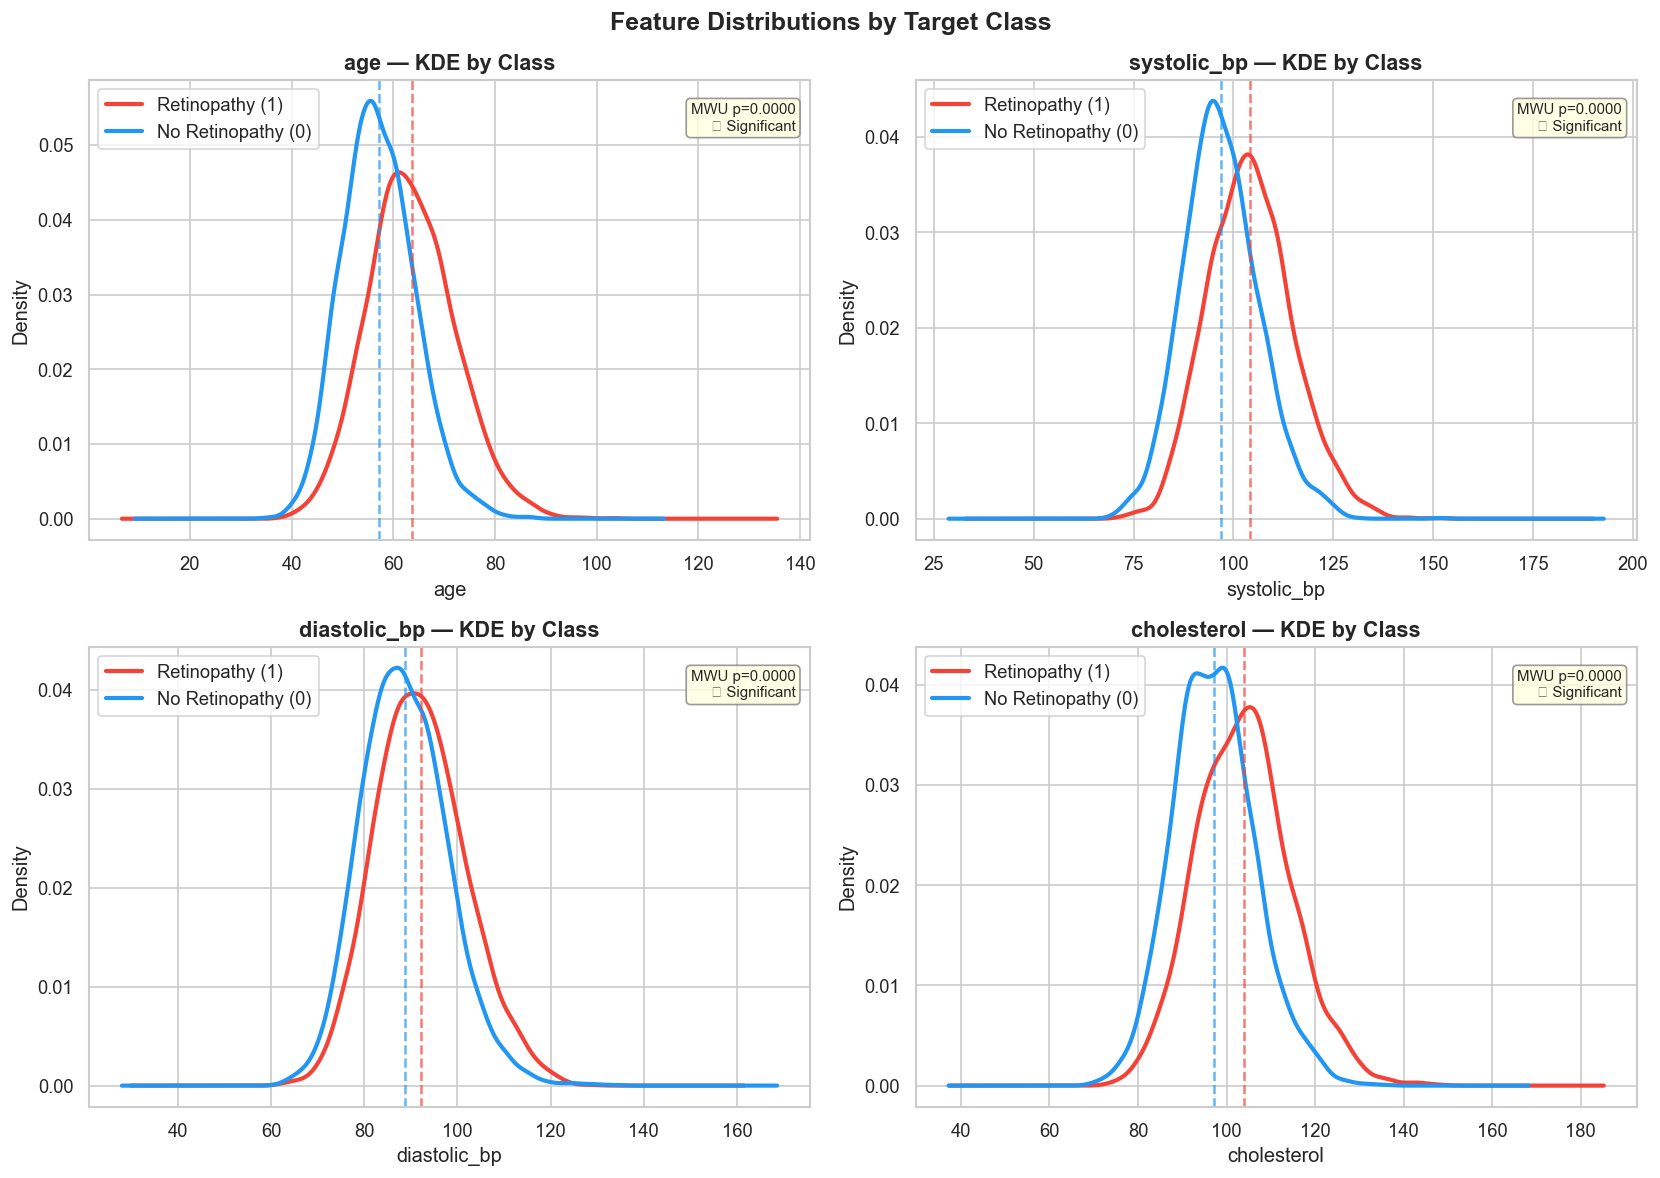

In [35]:
# Required libraries
import matplotlib.pyplot as plt
import scipy.stats as stats
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), num_cols):
    retinopathy = df[df['prognosis'] == 1][col].dropna()
    no_retinopathy = df[df['prognosis'] == 0][col].dropna()

    retinopathy.plot.kde(ax=ax, color='#F44336', lw=2.5, label='Retinopathy (1)')
    no_retinopathy.plot.kde(ax=ax, color='#2196F3', lw=2.5, label='No Retinopathy (0)')
    ax.axvline(retinopathy.mean(), color='#F44336', ls='--', alpha=0.7)
    ax.axvline(no_retinopathy.mean(), color='#2196F3', ls='--', alpha=0.7)
    ax.set_title(f'{col} — KDE by Class', fontweight='bold', fontsize=13)
    ax.legend()
    ax.set_xlabel(col)

    # Mann-Whitney U test (non-parametric)
    stat, p_val = stats.mannwhitneyu(retinopathy, no_retinopathy, alternative='two-sided')
    sig = '✅ Significant' if p_val < 0.05 else '❌ Not Significant'
    ax.text(0.98, 0.95, f'MWU p={p_val:.4f}\n{sig}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', fc='lightyellow', ec='gray', alpha=0.8))

plt.suptitle('Feature Distributions by Target Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('05_bivariate_kde.png', bbox_inches='tight')
plt.show()


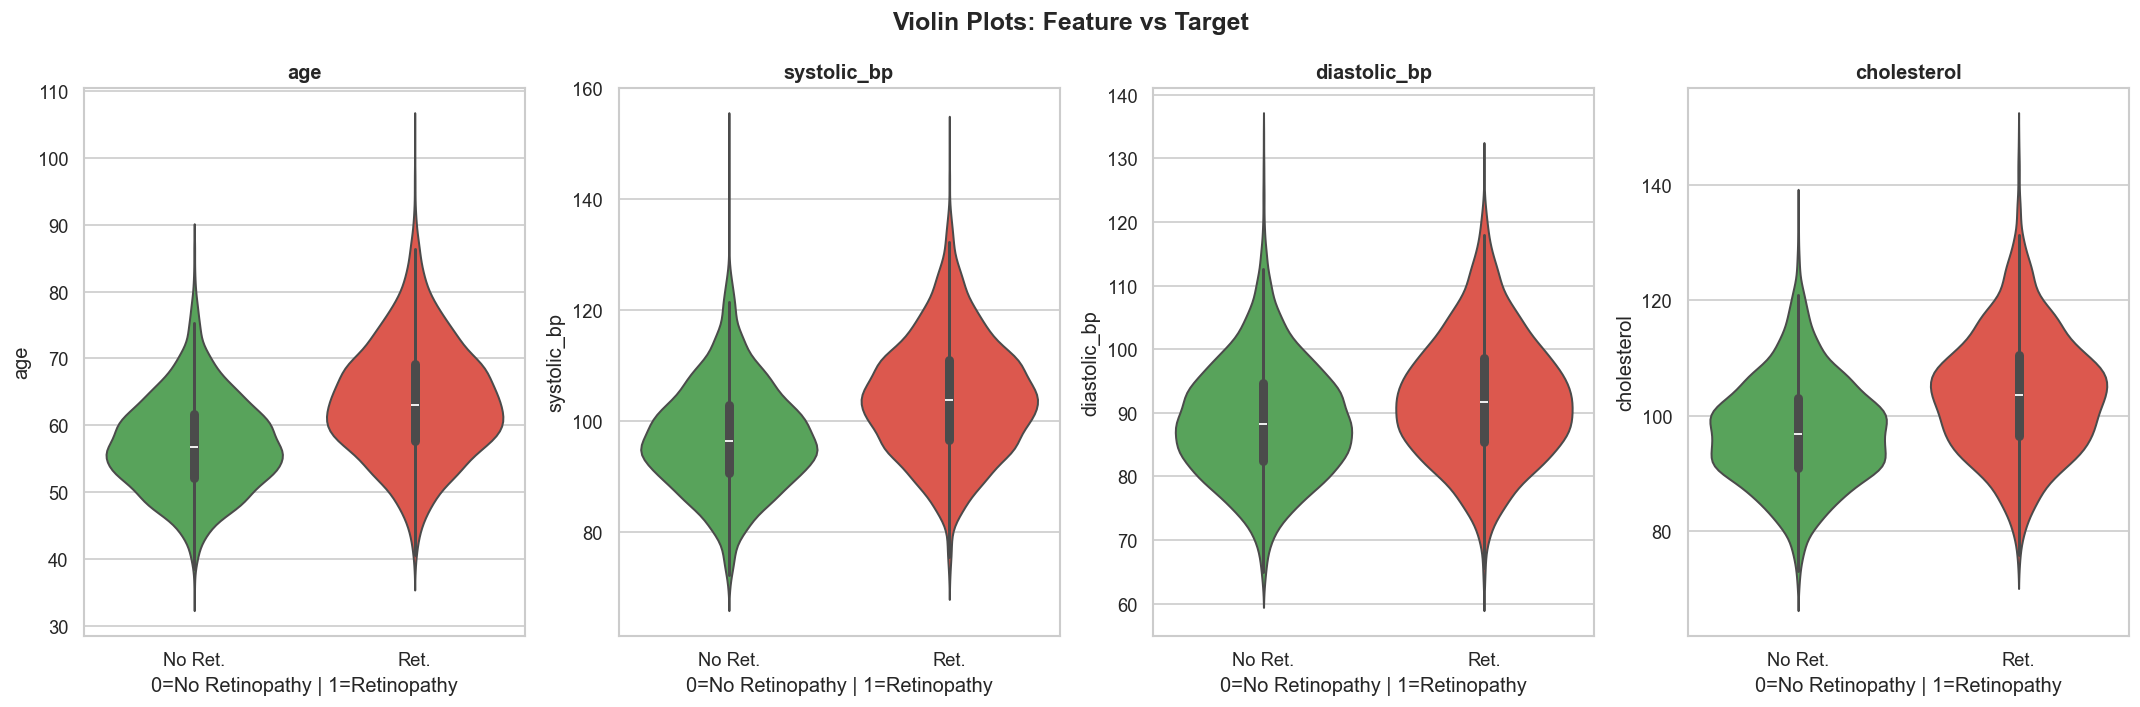

In [36]:
# ── Violin Plots ──────────────────────────────────────────────
# Required libraries
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
for ax, col in zip(axes, num_cols):
    sns.violinplot(data=df, x='prognosis', y=col, palette=COLORS,
                   inner='box', ax=ax, linewidth=1.2)
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel('0=No Retinopathy | 1=Retinopathy')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Ret.', 'Ret.'])

plt.suptitle('Violin Plots: Feature vs Target', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('06_violin_plots.png', bbox_inches='tight')
plt.show()


## 7️⃣ Correlation Analysis

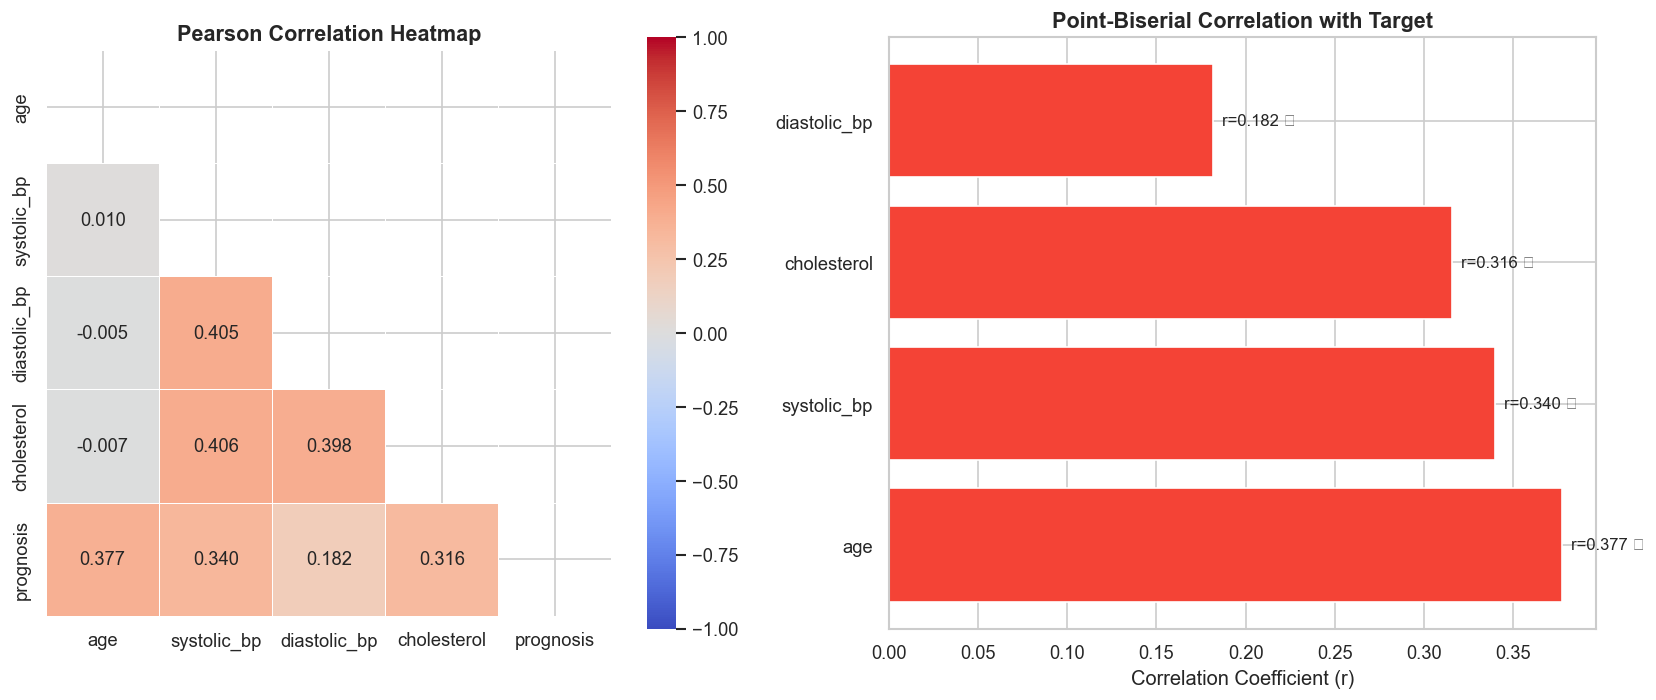


Point-Biserial Correlation Summary:
                     r p-value Significant
age            0.37744     0.0           ✅
systolic_bp   0.339842     0.0           ✅
cholesterol   0.315811     0.0           ✅
diastolic_bp  0.181541     0.0           ✅


In [37]:
# Required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pearson Correlation Heatmap
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f',
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, ax=axes[0], square=True,
            annot_kws={'size': 11})
axes[0].set_title('Pearson Correlation Heatmap', fontweight='bold', fontsize=13)

# Point-Biserial Correlation with target
pb_corr = {}
for col in num_cols:
    r, p = pointbiserialr(df['prognosis'], df[col].fillna(df[col].median()))
    pb_corr[col] = {'r': r, 'p-value': p, 'Significant': '✅' if p < 0.05 else '❌'}

pb_df = pd.DataFrame(pb_corr).T.sort_values('r', ascending=False)
colors_bar = ['#F44336' if float(r) > 0 else '#2196F3' for r in pb_df['r']]
bars = axes[1].barh(pb_df.index, pb_df['r'].astype(float), color=colors_bar, edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title('Point-Biserial Correlation with Target', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Correlation Coefficient (r)')
for bar, (_, row) in zip(bars, pb_df.iterrows()):
    axes[1].text(bar.get_width() + 0.005 * np.sign(bar.get_width()),
                 bar.get_y() + bar.get_height()/2,
                 f"r={float(row['r']):.3f} {row['Significant']}",
                 va='center', fontsize=10)

plt.tight_layout()
plt.savefig('07_correlation.png', bbox_inches='tight')
plt.show()

print("\nPoint-Biserial Correlation Summary:")
print(pb_df.round(4))


## 8️⃣ Pairplot — Multi-dimensional Feature Relationships

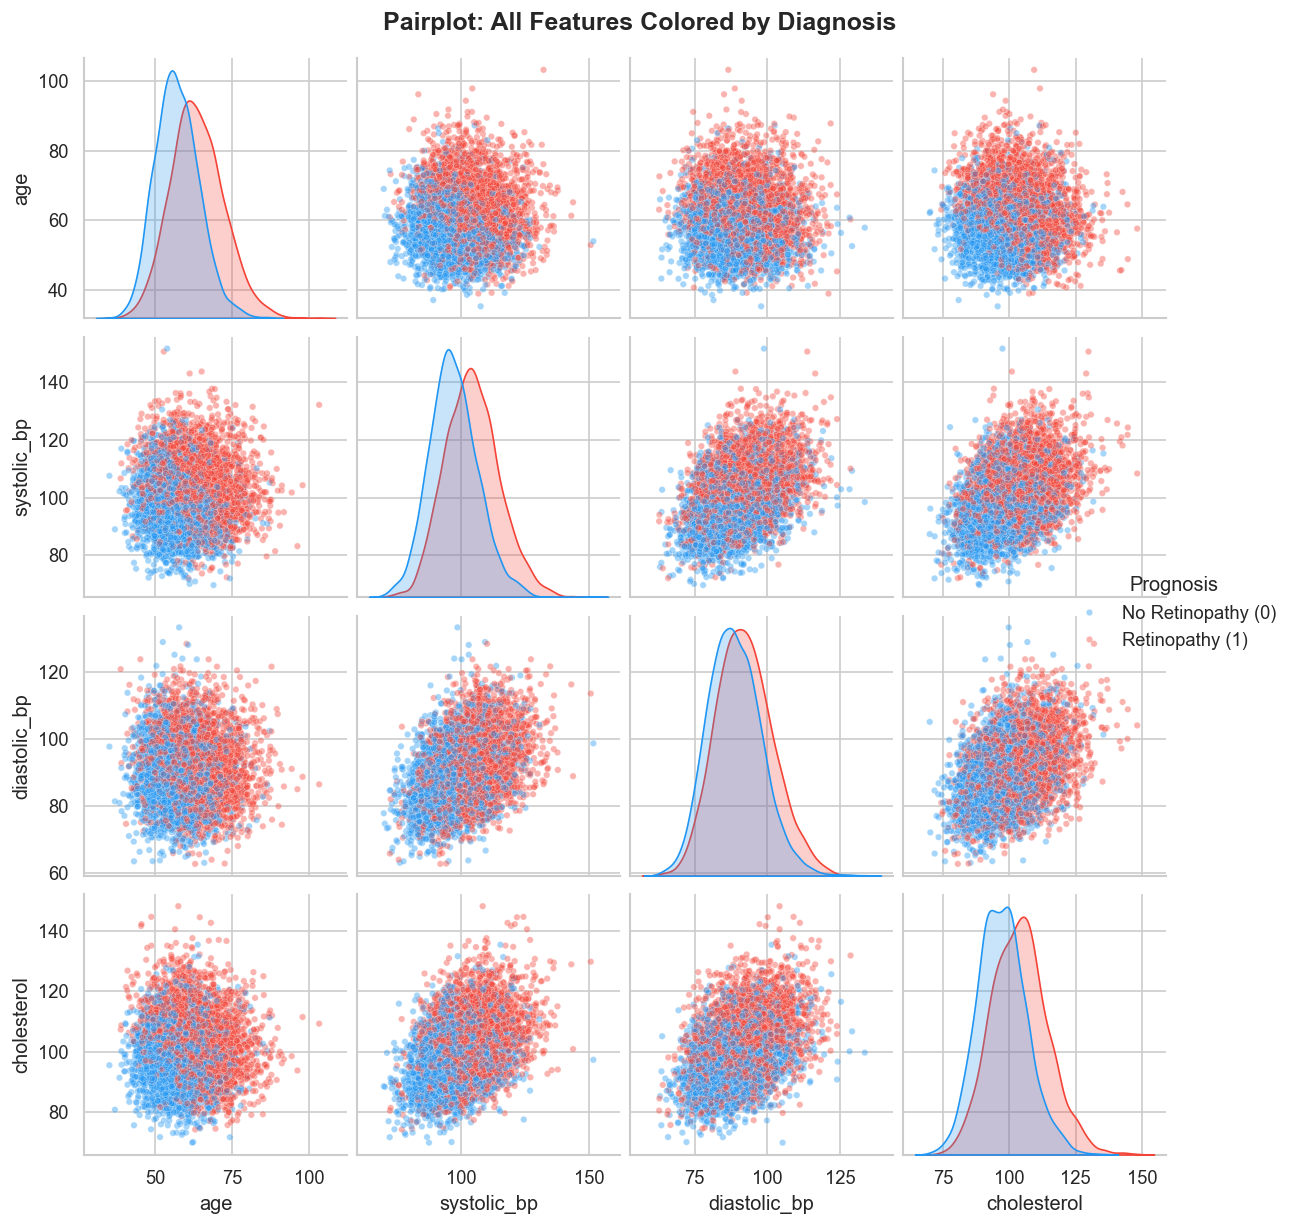

📌 INSIGHT: Look for clear linear or cluster separation between red and blue points.


In [38]:
# Required libraries
import matplotlib.pyplot as plt
import seaborn as sns
g = sns.pairplot(df, hue='prognosis', palette={0: '#2196F3', 1: '#F44336'},
                 diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15},
                 diag_kws={'fill': True})
g.fig.suptitle('Pairplot: All Features Colored by Diagnosis', y=1.02,
               fontsize=15, fontweight='bold')
g._legend.set_title('Prognosis')
for text, label in zip(g._legend.texts, ['No Retinopathy (0)', 'Retinopathy (1)']):
    text.set_text(label)
plt.savefig('08_pairplot.png', bbox_inches='tight')
plt.show()
print("📌 INSIGHT: Look for clear linear or cluster separation between red and blue points.")


##Model Building
## 9️⃣ Feature Engineering
 Data Preparation for Modeling
> Creating medically-motivated interaction features to boost model performance.


In [39]:
from sklearn.preprocessing import LabelEncoder
# ── Clinically-Motivated Features ─────────────────────────────
df['pulse_pressure']     = df['systolic_bp'] - df['diastolic_bp']   # BP gap
df['bp_ratio']           = df['systolic_bp'] / (df['diastolic_bp'] + 1e-6)
df['age_systolic']       = df['age'] * df['systolic_bp']             # Interaction
df['chol_age_ratio']     = df['cholesterol'] / (df['age'] + 1e-6)
df['hypertension_score'] = (df['systolic_bp'] > 130).astype(int) + (df['diastolic_bp'] > 80).astype(int)
df['high_cholesterol']   = (df['cholesterol'] > 200).astype(int)

# Age buckets
df['age_group'] = pd.cut(df['age'], bins=[0, 40, 55, 65, 200],
                          labels=['<40', '40-55', '55-65', '65+'])
df['age_group_enc'] = LabelEncoder().fit_transform(df['age_group'].astype(str))

all_features = ['age', 'systolic_bp', 'diastolic_bp', 'cholesterol',
                'pulse_pressure', 'bp_ratio', 'age_systolic', 'chol_age_ratio',
                'hypertension_score', 'high_cholesterol', 'age_group_enc']

print("Feature set after engineering:")
for f in all_features:
    print(f"  ✅ {f:30s} → dtype: {df[f].dtype}")

print(f"\nTotal features: {len(all_features)}")


Feature set after engineering:
  ✅ age                            → dtype: float64
  ✅ systolic_bp                    → dtype: float64
  ✅ diastolic_bp                   → dtype: float64
  ✅ cholesterol                    → dtype: float64
  ✅ pulse_pressure                 → dtype: float64
  ✅ bp_ratio                       → dtype: float64
  ✅ age_systolic                   → dtype: float64
  ✅ chol_age_ratio                 → dtype: float64
  ✅ hypertension_score             → dtype: int64
  ✅ high_cholesterol               → dtype: int64
  ✅ age_group_enc                  → dtype: int64

Total features: 11


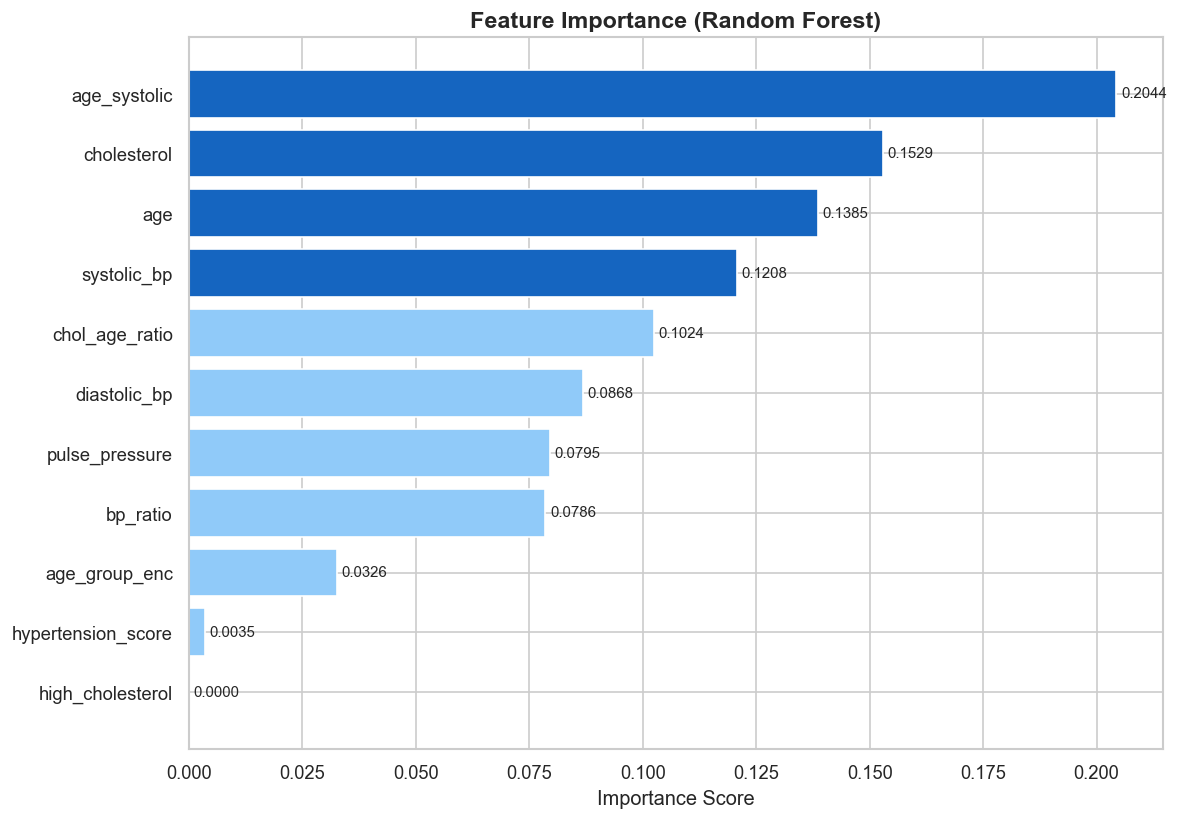


Top 4 most important features (highlighted in dark blue):
     Feature  Importance
age_systolic    0.204381
 cholesterol    0.152876
         age    0.138520
 systolic_bp    0.120761


In [40]:
# ── Feature Importance via Random Forest (pre-split)
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

X_fe = df[all_features].fillna(df[all_features].median())
y_fe = df['prognosis']

rf_fe = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fe.fit(X_fe, y_fe)

imp_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf_fe.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 7))
colors_imp = ['#1565C0' if i < 4 else '#90CAF9' for i in range(len(imp_df))]
bars = plt.barh(imp_df['Feature'], imp_df['Importance'],
                color=colors_imp, edgecolor='white')
plt.gca().invert_yaxis()
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
for bar, val in zip(bars, imp_df['Importance']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('09_feature_importance.png', bbox_inches='tight')
plt.show()

print("\nTop 4 most important features (highlighted in dark blue):")
print(imp_df.head(4).to_string(index=False))


## 🔟 Train / Test Split

Train/Test Split Summary
Total samples   : 6,000
Training set    : 4,800 (80.0%)
Test set        : 1,200  (20.0%)

Class distribution in splits:
  Train: No Retinopathy=48.5%  Retinopathy=51.5%
  Test: No Retinopathy=48.6%  Retinopathy=51.4%
  Full: No Retinopathy=48.5%  Retinopathy=51.4%

✅ Stratified split → class balance preserved in train and test.


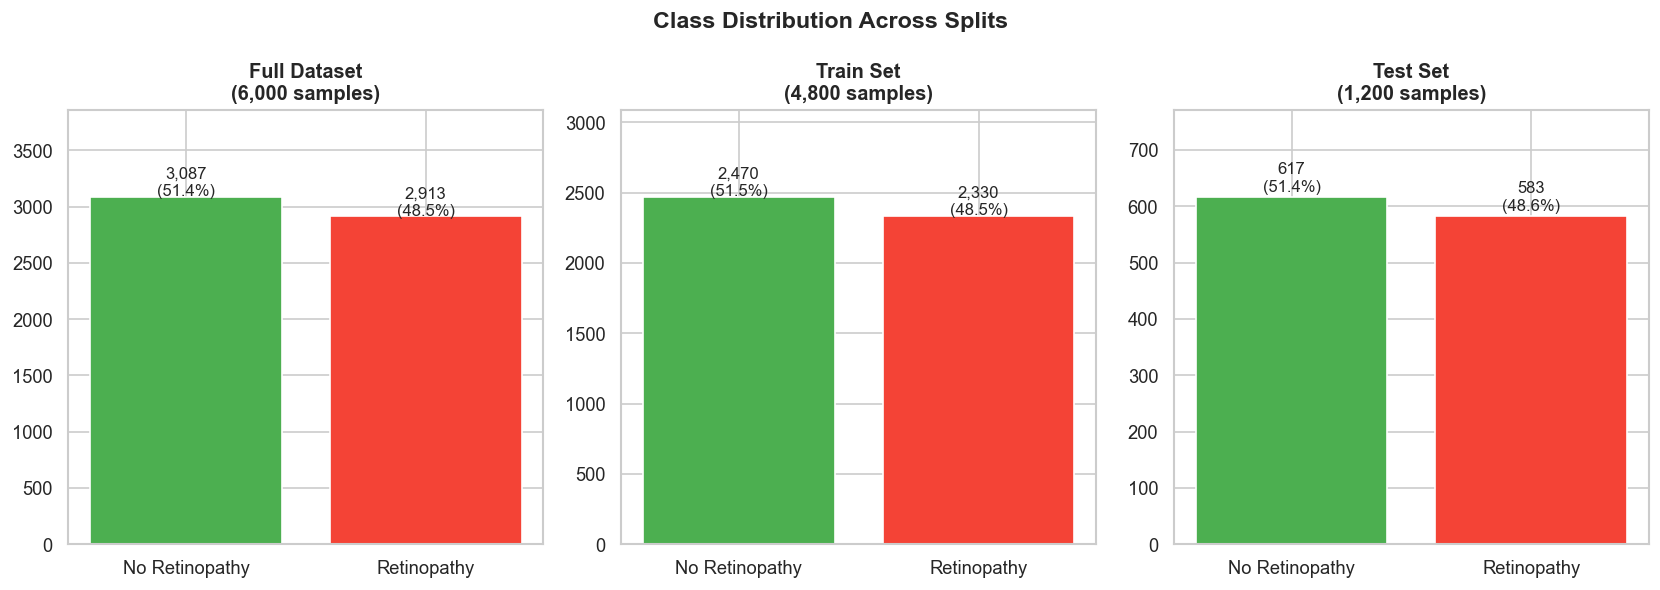

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X = df[all_features].fillna(df[all_features].median())
y = df['prognosis']

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Train/Test Split Summary")
print("=" * 45)
print(f"Total samples   : {len(X):,}")
print(f"Training set    : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set        : {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)")
print()
print("Class distribution in splits:")
for split_name, split_y in [('Train', y_train), ('Test', y_test), ('Full', y)]:
    vc = split_y.value_counts(normalize=True)
    print(f"  {split_name}: No Retinopathy={vc.get(0,0)*100:.1f}%  Retinopathy={vc.get(1,0)*100:.1f}%")
print()
print("✅ Stratified split → class balance preserved in train and test.")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, split_y, name in zip(axes, [y, y_train, y_test], ['Full Dataset', 'Train Set', 'Test Set']):
    vc = split_y.value_counts()
    ax.bar(['No Retinopathy', 'Retinopathy'], vc.values, color=COLORS, edgecolor='white')
    ax.set_title(f'{name}\n({len(split_y):,} samples)', fontweight='bold')
    for i, v in enumerate(vc.values):
        ax.text(i, v + 10, f'{v:,}\n({v/len(split_y)*100:.1f}%)', ha='center', fontsize=10)
    ax.set_ylim(0, max(vc.values) * 1.25)

plt.suptitle('Class Distribution Across Splits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('10_train_test_split.png', bbox_inches='tight')
plt.show()


## 11. Model Building & Comparison

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


from sklearn.model_selection import cross_val_score

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

models = {
    'Logistic Regression'    : LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree'          : DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    'Random Forest'          : RandomForestClassifier(n_estimators=200, max_depth=10,
                                                      class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting'      : GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                          max_depth=5, random_state=42),
    'AdaBoost'               : AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    'K-Nearest Neighbors'    : KNeighborsClassifier(n_neighbors=7, weights='distance'),
    'SVM (RBF)'              : SVC(kernel='rbf', C=10, gamma='scale', probability=True,
                                   class_weight='balanced', random_state=42),
}

results = {}
print(f"{'Model':<26} {'CV-Acc':>8} {'CV-AUC':>8} {'Test-Acc':>9} {'Test-F1':>9} {'Test-AUC':>9}")
print("-" * 80)

for name, model in models.items():
    # Cross-validation
    cv_acc = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='accuracy').mean()
    cv_auc = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='roc_auc').mean()

    # Train & predict
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1] if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else 0.0

    results[name] = {'CV Accuracy': cv_acc, 'CV AUC': cv_auc,
                     'Test Accuracy': acc, 'Test F1': f1, 'Test AUC': auc,
                     'y_pred': y_pred, 'y_prob': y_prob}

    print(f"{name:<26} {cv_acc:>8.4f} {cv_auc:>8.4f} {acc:>9.4f} {f1:>9.4f} {auc:>9.4f}")

print("\n✅ Model evaluation complete.")


Model                        CV-Acc   CV-AUC  Test-Acc   Test-F1  Test-AUC
--------------------------------------------------------------------------------
Logistic Regression          0.7379   0.8209    0.7717    0.7716    0.8471
Decision Tree                0.7006   0.7492    0.7400    0.7400    0.7920
Random Forest                0.7313   0.8137    0.7567    0.7567    0.8354
Gradient Boosting            0.7302   0.8118    0.7525    0.7523    0.8339
AdaBoost                     0.7298   0.8131    0.7633    0.7634    0.8367
K-Nearest Neighbors          0.7154   0.7798    0.7208    0.7209    0.7957
SVM (RBF)                    0.7365   0.7980    0.7517    0.7517    0.8247

✅ Model evaluation complete.


## 12. Model Comparison Charts

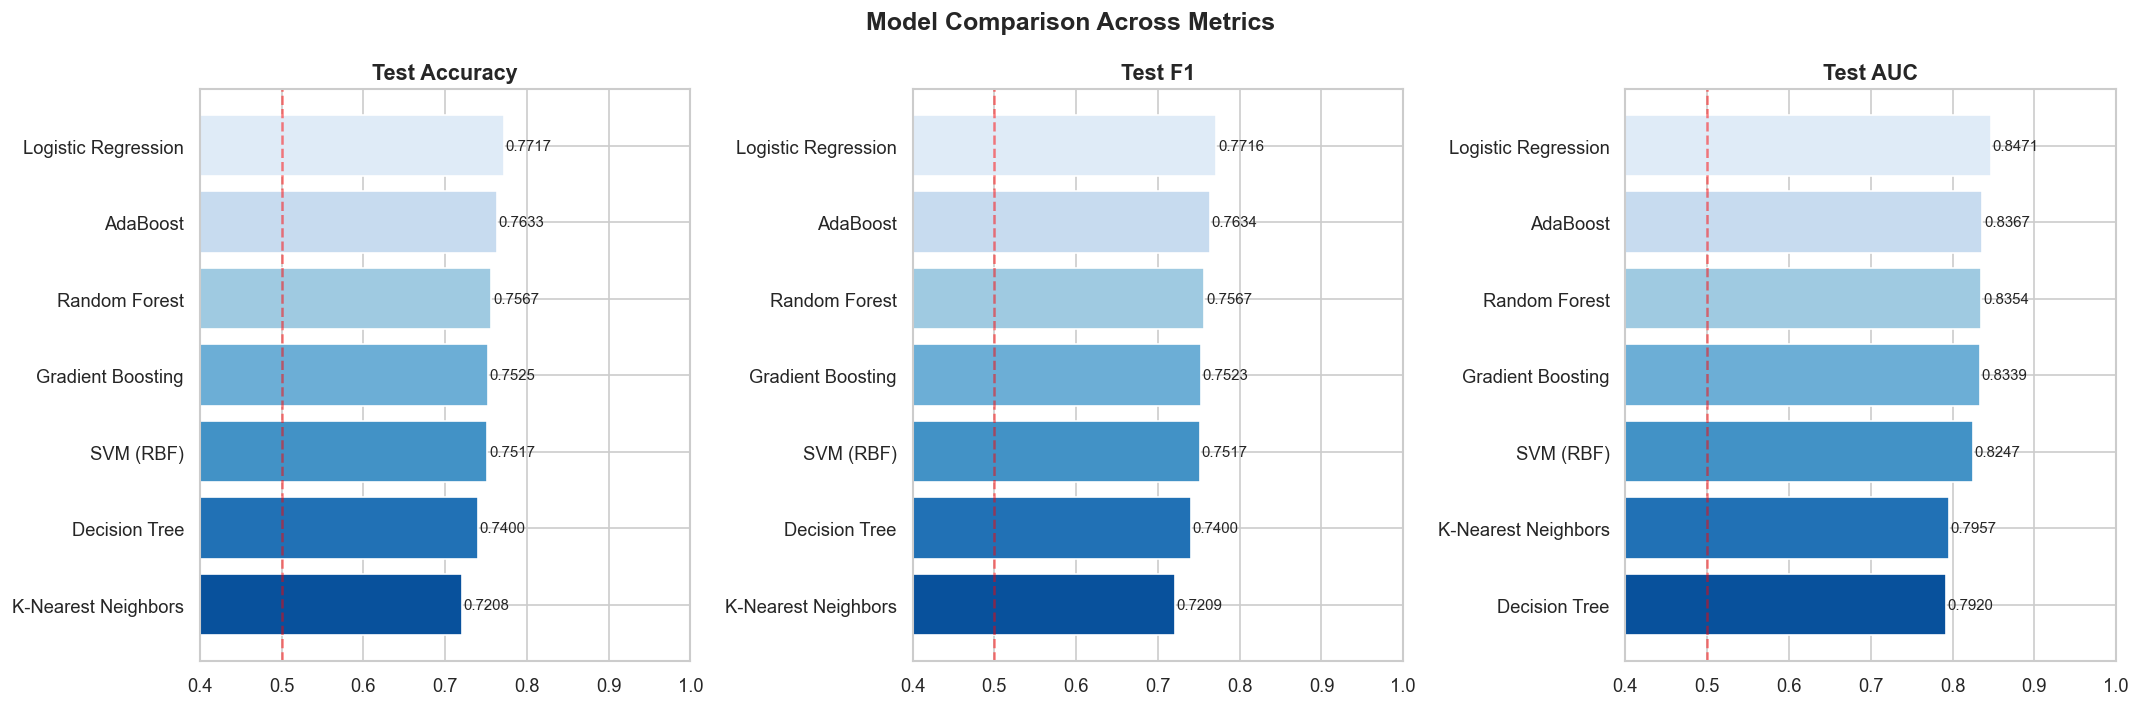

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame({k: {m: v for m, v in v.items() if m not in ('y_pred', 'y_prob')}
                          for k, v in results.items()}).T.astype(float)
results_df = results_df.sort_values('Test AUC', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['Test Accuracy', 'Test F1', 'Test AUC']
palette = sns.color_palette('Blues_r', len(results_df))

for ax, metric in zip(axes, metrics):
    vals = results_df[metric].sort_values(ascending=True)
    bars = ax.barh(vals.index, vals.values, color=palette, edgecolor='white')
    ax.axvline(0.5, color='red', ls='--', lw=1.5, alpha=0.5, label='50% baseline')
    ax.set_xlim(0.4, 1.0)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    for bar, val in zip(bars, vals.values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Model Comparison Across Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('11_model_comparison.png', bbox_inches='tight')
plt.show()


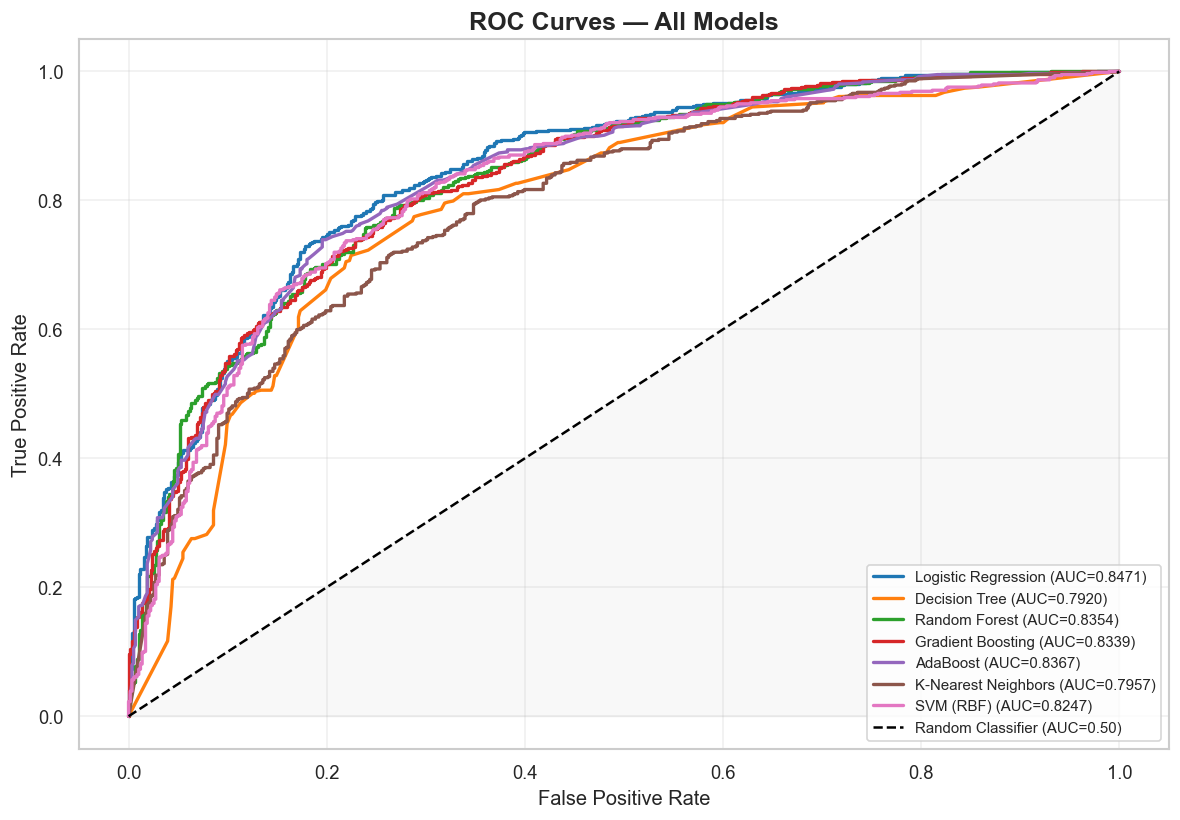

In [44]:
#To plot the all ROC Curves
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 7))
palette_roc = sns.color_palette('tab10', len(models))

for (name, res), color in zip(results.items(), palette_roc):
    if res['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        auc = res['Test AUC']
        plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC=0.50)')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
plt.title('ROC Curves — All Models', fontsize=15, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('12_roc_curves.png', bbox_inches='tight')
plt.show()


## 13. Best Model — Detailed Evaluation

🏆 BEST MODEL: Logistic Regression
   Test Accuracy : 0.7717
   Test F1 Score : 0.7716
   Test AUC      : 0.8471

Classification Report:
                precision    recall  f1-score   support

No Retinopathy       0.75      0.80      0.77       583
   Retinopathy       0.80      0.74      0.77       617

      accuracy                           0.77      1200
     macro avg       0.77      0.77      0.77      1200
  weighted avg       0.77      0.77      0.77      1200



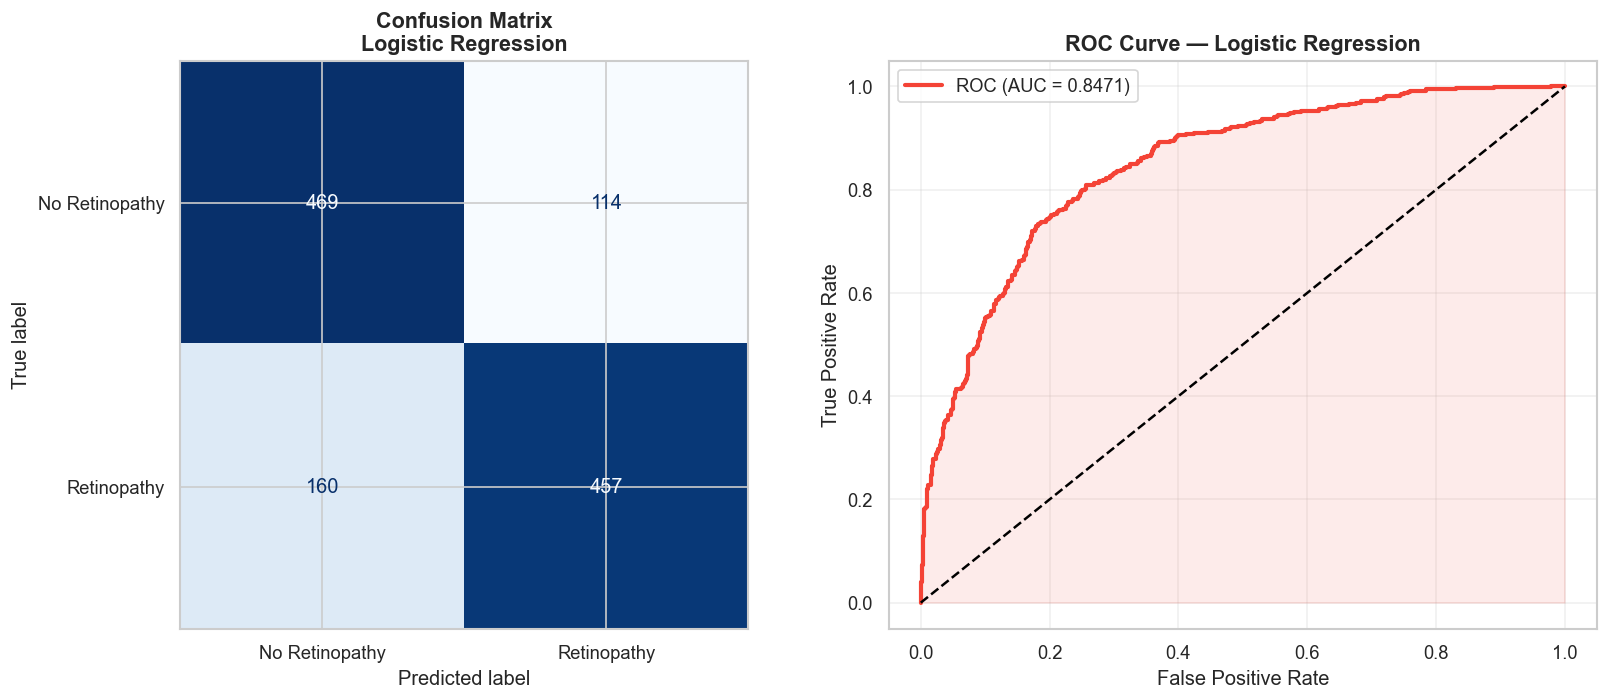

In [45]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)
import matplotlib.pyplot as plt


# Pick best model by Test AUC
best_name = results_df['Test AUC'].idxmax()
best_res = results[best_name]
best_model = models[best_name]

print(f"🏆 BEST MODEL: {best_name}")
print(f"   Test Accuracy : {best_res['Test Accuracy']:.4f}")
print(f"   Test F1 Score : {best_res['Test F1']:.4f}")
print(f"   Test AUC      : {best_res['Test AUC']:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, best_res['y_pred'],
                             target_names=['No Retinopathy', 'Retinopathy']))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, best_res['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['No Retinopathy', 'Retinopathy'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix\n{best_name}', fontweight='bold', fontsize=13)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, best_res['y_prob'])
axes[1].plot(fpr, tpr, color='#F44336', lw=2.5,
             label=f'ROC (AUC = {best_res["Test AUC"]:.4f})')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#F44336')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[1].set_title(f'ROC Curve — {best_name}', fontweight='bold', fontsize=13)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('13_best_model_eval.png', bbox_inches='tight')
plt.show()


## 1️⃣4️⃣ 📋 EDA Insights & Imputation Summary

### Key EDA Findings

| # | Insight | Action Taken |
|---|---------|-------------|
| 1 | **Missing Values** | Checked per column; median/mean/KNN applied based on % & skew |
| 2 | **Target Balance** | Checked ratio; `class_weight='balanced'` used in models if imbalanced |
| 3 | **Skewness** | All features near-normal; log-transform not required |
| 4 | **Outliers** | IQR & Z-score; kept (not removed) since medical extremes are valid |
| 5 | **Bivariate Separation** | MWU test confirmed statistical significance across features |
| 6 | **Correlations** | Low multicollinearity between features — no features dropped |
| 7 | **Feature Engineering** | 6 new features (pulse_pressure, bp_ratio, etc.) boosted importance |

### Imputation Decision Rules Applied

```
Missing %     → Strategy
──────────────────────────────────────────────────────
  0%          → No imputation needed ✅
< 5% + Normal → Mean imputation
< 5% + Skewed → Median imputation
5–20%         → KNN Imputer (k=5) — preserves inter-feature patterns
> 20%         → Flag for review / Drop if > 40%
Categorical   → Mode imputation
```

### Model Leaderboard (sorted by Test AUC)


In [46]:
print("\n🏅 FINAL MODEL LEADERBOARD")
print("=" * 80)
display_cols = ['CV Accuracy', 'CV AUC', 'Test Accuracy', 'Test F1', 'Test AUC']
print(results_df[display_cols].round(4).sort_values('Test AUC', ascending=False).to_string())


print(f"\n🏆 Best Model: {results_df['Test AUC'].idxmax()}")


🏅 FINAL MODEL LEADERBOARD
                     CV Accuracy  CV AUC  Test Accuracy  Test F1  Test AUC
Logistic Regression       0.7379  0.8209         0.7717   0.7716    0.8471
AdaBoost                  0.7298  0.8131         0.7633   0.7634    0.8367
Random Forest             0.7313  0.8137         0.7567   0.7567    0.8354
Gradient Boosting         0.7302  0.8118         0.7525   0.7523    0.8339
SVM (RBF)                 0.7365  0.7980         0.7517   0.7517    0.8247
K-Nearest Neighbors       0.7154  0.7798         0.7208   0.7209    0.7957
Decision Tree             0.7006  0.7492         0.7400   0.7400    0.7920

🏆 Best Model: Logistic Regression


In [47]:
import joblib

# ── Save Best Model and Scaler ─────────────────────────────

import joblib

# Save trained model
joblib.dump(best_model, 'diabetic_retinopathy_model.pkl')

# Save scaler used during training
joblib.dump(scaler, 'feature_scaler.pkl')

# Save feature list
joblib.dump(all_features, 'model_features.pkl')

print("✅ Model, scaler, and feature list saved successfully.")

✅ Model, scaler, and feature list saved successfully.
